### Deep learning model training.
#### Top accuracy:
|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|92.1%|95.7%|2026.4.7|    
|deeplabv3plus_mb2|93.4%|97.2%|2026.4.8|    
|UNet_att|93.0%|96.8%|2026.4.7|    

#### Note: 
1. when use unet, the bn parameters should be frozen using model.eval().  


In [1]:
import time
import torch
import random
import numpy as np 
import pandas as pd 
import torch.nn as nn
from glob import glob
from notebooks import config
import matplotlib.pyplot as plt
from pyrsimg import imsShow
from utils.utils import read_scenes
from utils.metrics import oa_binary, miou_binary
from utils.data_loader import SceneArraySet, PatchPathSet
from utils.data_aug import GaussianNoise
from torchvision.transforms import v2
from model import unet, unet_att, deeplabv3plus, deeplabv3plus_mobilev2


/home/xin/miniconda3/envs/watnet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
patch_size = 512  ## patch size setting
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 172
vali patch 512: 217


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 
scene_truth_ls =  list(zip(scenes_arr, truths_arr))
scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
                             for scene, truth in scene_truth_ls] 


In [4]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size), padding = 50, fill=0),
      v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
      v2.RandomHorizontalFlip(p=0.3),
      v2.RandomVerticalFlip(p=0.3),
      GaussianNoise(mean=0, sigma_max=0.1, p=0.3)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])


In [5]:
tra_dset = SceneArraySet(scene_truth_list = scene_truth_ls, 
                          transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, 
                          transforms=transforms_val)
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dset, 
                                         batch_size=4,
                                         num_workers=5) 


#### Model training

In [6]:
### check model
# model = unet(num_bands=6)
# model = unet_att(num_bands=6)
# model = deeplabv3plus(num_bands=6)
model = deeplabv3plus_mobilev2(num_bands=6)


In [7]:
input_tensor = torch.randn(2, 6, 512, 512)  
output = model(input_tensor) 
print(output.shape)


torch.Size([2, 1, 512, 512])


In [8]:
### create loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='min', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [9]:
'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    miou = miou_binary(pred=pred, truth=y)
    oa = oa_binary(pred=pred, truth=y)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    with torch.no_grad():
        pred = model(x)
        loss = loss_fn(pred, y)
    miou = miou_binary(pred=pred, truth=y)
    oa = oa_binary(pred=pred, truth=y)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, optimizer, 
                    tra_loader, val_loader,                     
                    epoches, device, 
                    lr_scheduler=None):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    epoch_record = []
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----1. train the model-----'''
        if epoch < 30: model.train()   ## Training mode for the first 30 epochs, then switch to eval mode to fix the bn stats 
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                            optimizer=optimizer, 
                                            x=x_batch, 
                                            y=y_batch)
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        '''----- 2. validate the model: time consuming -----'''
        model.eval()
        if epoch % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                loss, miou, oa = val_step(model=model, 
                                            loss_fn=loss_fn, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
                val_loss += loss.item()
                val_miou += miou.item()
                val_oa += oa.item()
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            val_loss = val_loss/size_val_loader
            val_miou = val_miou/size_val_loader
            val_oa = val_oa/size_val_loader
            tra_loss_loops.append(tra_loss); tra_miou_loops.append(tra_miou); tra_oa_loops.append(tra_oa)
            val_loss_loops.append(val_loss); val_miou_loops.append(val_miou); val_oa_loops.append(val_oa)
            epoch_record.append(epoch)
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, '
                    f'val-> Loss:{val_loss:.3f},Oa:{val_oa:.3f}, Miou:{val_miou:.3f},time:{time.time()-start:.1f}s')
        else: 
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(val_loss)    ## if using ReduceLROnPlateau
        '''----- 3. show the result -----'''
        if epoch%20 == 0:
            sam_index = random.randrange(len(val_dset))
            patch_val, truth_val = val_dset[sam_index]
            patch_val, truth_val = patch_val.unsqueeze(0).to(device), truth_val.to(device)            
            pred_val = model(patch_val) 
            ## convert to numpy and plot
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch_val, pred_val, truth_val], 
                    clip_list = (2,0,0),
                    img_name_list=['patch', 'pred', 'truth'], 
                    color_bands_list=([3,2,2], 0, 0),                    
                    figsize=(9, 2.5))
            plt.tight_layout() 
            plt.show()
    metrics = {'epoch':epoch_record,'tra_loss':tra_loss_loops, 'tra_miou':tra_miou_loops, 'tra_oa': tra_oa_loops, 
                'val_loss': val_loss_loops, 'val_miou': val_miou_loops, 'val_oa': val_oa_loops}
    return metrics 


Ep0: tra-> Loss:0.455,Oa:0.806,Miou:0.717, val-> Loss:0.333,Oa:0.898, Miou:0.770,time:16.4s


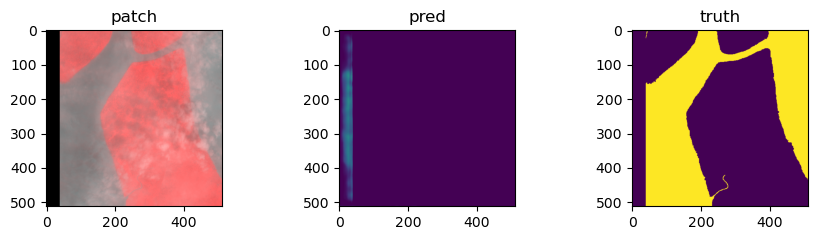

Ep1: tra-> Loss:0.299,Oa:0.874,Miou:0.785,                                 time:10.3s
Ep2: tra-> Loss:0.257,Oa:0.886,Miou:0.804,                                 time:10.3s
Ep3: tra-> Loss:0.256,Oa:0.888,Miou:0.790, val-> Loss:0.200,Oa:0.870, Miou:0.774,time:15.8s
Ep4: tra-> Loss:0.225,Oa:0.893,Miou:0.813,                                 time:10.3s
Ep5: tra-> Loss:0.237,Oa:0.879,Miou:0.769,                                 time:10.3s
Ep6: tra-> Loss:0.178,Oa:0.915,Miou:0.842, val-> Loss:0.166,Oa:0.928, Miou:0.858,time:15.8s
Ep7: tra-> Loss:0.188,Oa:0.917,Miou:0.824,                                 time:10.4s
Ep8: tra-> Loss:0.179,Oa:0.911,Miou:0.826,                                 time:10.3s
Ep9: tra-> Loss:0.157,Oa:0.916,Miou:0.837, val-> Loss:0.184,Oa:0.898, Miou:0.846,time:16.0s
Ep10: tra-> Loss:0.161,Oa:0.916,Miou:0.829,                                 time:10.3s
Ep11: tra-> Loss:0.162,Oa:0.908,Miou:0.818,                                 time:10.4s
Ep12: tra-> Loss:0.166,Oa:0.914,Mi

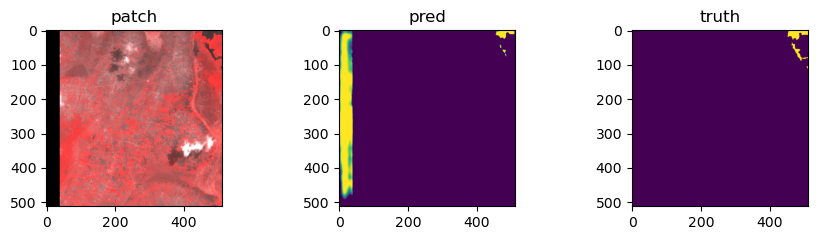

Ep21: tra-> Loss:0.142,Oa:0.910,Miou:0.845, val-> Loss:0.133,Oa:0.933, Miou:0.878,time:16.0s
Ep22: tra-> Loss:0.127,Oa:0.938,Miou:0.863,                                 time:10.4s
Ep23: tra-> Loss:0.123,Oa:0.923,Miou:0.857,                                 time:10.3s
Ep24: tra-> Loss:0.145,Oa:0.912,Miou:0.842, val-> Loss:0.136,Oa:0.911, Miou:0.863,time:15.9s
Ep25: tra-> Loss:0.113,Oa:0.942,Miou:0.862,                                 time:10.3s
Ep26: tra-> Loss:0.117,Oa:0.930,Miou:0.860,                                 time:10.4s
Ep27: tra-> Loss:0.131,Oa:0.920,Miou:0.863, val-> Loss:0.126,Oa:0.919, Miou:0.871,time:15.9s
Ep28: tra-> Loss:0.107,Oa:0.942,Miou:0.874,                                 time:10.3s
Ep29: tra-> Loss:0.113,Oa:0.933,Miou:0.866,                                 time:10.4s
Ep30: tra-> Loss:0.127,Oa:0.929,Miou:0.812, val-> Loss:0.190,Oa:0.869, Miou:0.816,time:15.4s
Ep31: tra-> Loss:0.125,Oa:0.936,Miou:0.855,                                 time:9.7s
Ep32: tra-> Loss:0.1

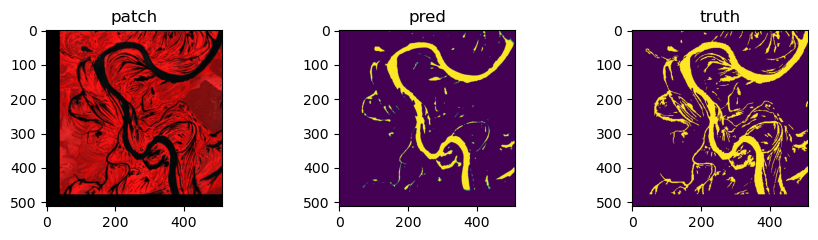

Ep41: tra-> Loss:0.075,Oa:0.961,Miou:0.909,                                 time:9.7s
Ep42: tra-> Loss:0.078,Oa:0.956,Miou:0.898, val-> Loss:0.070,Oa:0.963, Miou:0.888,time:15.3s
Ep43: tra-> Loss:0.066,Oa:0.966,Miou:0.912,                                 time:9.7s
Ep44: tra-> Loss:0.064,Oa:0.961,Miou:0.913,                                 time:9.6s
Ep45: tra-> Loss:0.063,Oa:0.964,Miou:0.906, val-> Loss:0.062,Oa:0.962, Miou:0.903,time:15.2s
Ep46: tra-> Loss:0.088,Oa:0.962,Miou:0.883,                                 time:9.7s
Ep47: tra-> Loss:0.077,Oa:0.948,Miou:0.900,                                 time:9.8s
Ep48: tra-> Loss:0.074,Oa:0.954,Miou:0.909, val-> Loss:0.066,Oa:0.959, Miou:0.901,time:15.3s
Ep49: tra-> Loss:0.066,Oa:0.961,Miou:0.914,                                 time:9.7s
Ep50: tra-> Loss:0.066,Oa:0.957,Miou:0.909,                                 time:9.6s
Ep51: tra-> Loss:0.065,Oa:0.964,Miou:0.914, val-> Loss:0.068,Oa:0.954, Miou:0.892,time:15.2s
Ep52: tra-> Loss:0.058,Oa:

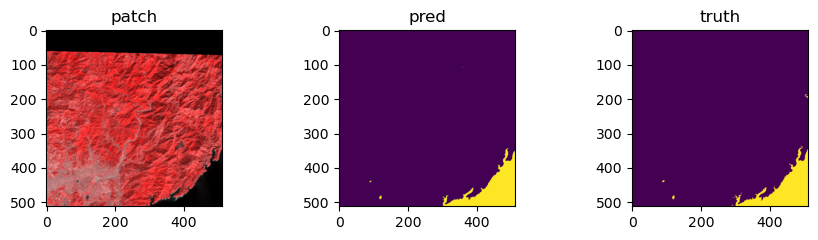

Ep61: tra-> Loss:0.059,Oa:0.973,Miou:0.934,                                 time:9.7s
Ep62: tra-> Loss:0.062,Oa:0.965,Miou:0.917,                                 time:9.7s
Ep63: tra-> Loss:0.080,Oa:0.960,Miou:0.911, val-> Loss:0.066,Oa:0.971, Miou:0.886,time:15.2s
Ep64: tra-> Loss:0.074,Oa:0.962,Miou:0.904,                                 time:9.7s
Ep65: tra-> Loss:0.071,Oa:0.961,Miou:0.912,                                 time:9.7s
Ep66: tra-> Loss:0.063,Oa:0.966,Miou:0.908, val-> Loss:0.059,Oa:0.959, Miou:0.907,time:15.4s
Ep67: tra-> Loss:0.068,Oa:0.956,Miou:0.902,                                 time:9.7s
Ep68: tra-> Loss:0.062,Oa:0.965,Miou:0.917,                                 time:9.7s
Ep69: tra-> Loss:0.051,Oa:0.971,Miou:0.929, val-> Loss:0.057,Oa:0.968, Miou:0.908,time:15.4s
Ep70: tra-> Loss:0.056,Oa:0.965,Miou:0.915,                                 time:9.7s
Ep71: tra-> Loss:0.056,Oa:0.966,Miou:0.922,                                 time:9.8s
Ep72: tra-> Loss:0.054,Oa:0.966,M

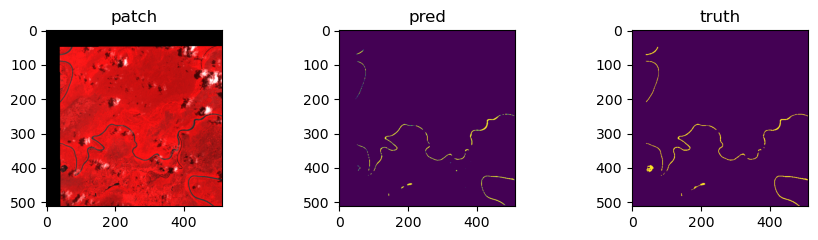

Ep81: tra-> Loss:0.058,Oa:0.971,Miou:0.926, val-> Loss:0.058,Oa:0.955, Miou:0.917,time:15.4s
Ep82: tra-> Loss:0.049,Oa:0.973,Miou:0.937,                                 time:9.7s
Ep83: tra-> Loss:0.059,Oa:0.958,Miou:0.911,                                 time:9.7s
Ep84: tra-> Loss:0.050,Oa:0.973,Miou:0.938, val-> Loss:0.065,Oa:0.955, Miou:0.914,time:15.2s
Ep85: tra-> Loss:0.057,Oa:0.965,Miou:0.918,                                 time:9.7s
Ep86: tra-> Loss:0.056,Oa:0.969,Miou:0.916,                                 time:9.8s
Ep87: tra-> Loss:0.049,Oa:0.969,Miou:0.934, val-> Loss:0.057,Oa:0.967, Miou:0.916,time:15.2s
Ep88: tra-> Loss:0.053,Oa:0.972,Miou:0.928,                                 time:9.7s
Ep89: tra-> Loss:0.055,Oa:0.969,Miou:0.916,                                 time:9.7s
Ep90: tra-> Loss:0.049,Oa:0.971,Miou:0.930, val-> Loss:0.057,Oa:0.973, Miou:0.906,time:15.2s
Ep91: tra-> Loss:0.051,Oa:0.971,Miou:0.917,                                 time:9.7s
Ep92: tra-> Loss:0.060,Oa:

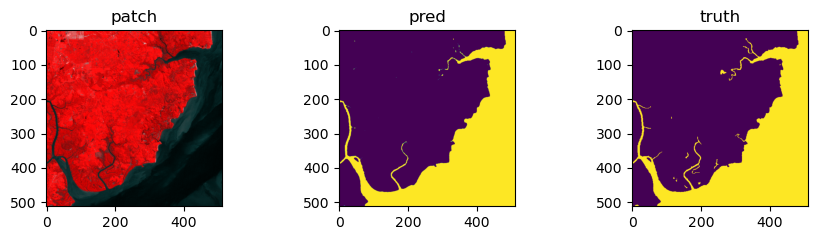

Ep101: tra-> Loss:0.054,Oa:0.971,Miou:0.927,                                 time:9.8s
Ep102: tra-> Loss:0.056,Oa:0.967,Miou:0.922, val-> Loss:0.065,Oa:0.962, Miou:0.905,time:15.3s
Ep103: tra-> Loss:0.052,Oa:0.972,Miou:0.925,                                 time:9.6s
Ep104: tra-> Loss:0.056,Oa:0.970,Miou:0.921,                                 time:9.7s
Ep105: tra-> Loss:0.055,Oa:0.970,Miou:0.925, val-> Loss:0.071,Oa:0.968, Miou:0.896,time:15.2s
Ep106: tra-> Loss:0.052,Oa:0.972,Miou:0.929,                                 time:9.8s
Ep107: tra-> Loss:0.047,Oa:0.975,Miou:0.933,                                 time:9.7s
Ep108: tra-> Loss:0.059,Oa:0.970,Miou:0.918, val-> Loss:0.061,Oa:0.960, Miou:0.914,time:15.2s
Ep109: tra-> Loss:0.052,Oa:0.973,Miou:0.927,                                 time:9.7s
Ep110: tra-> Loss:0.047,Oa:0.971,Miou:0.937,                                 time:9.7s
Ep111: tra-> Loss:0.051,Oa:0.971,Miou:0.930, val-> Loss:0.062,Oa:0.968, Miou:0.902,time:15.1s
Ep112: tra-> Lo

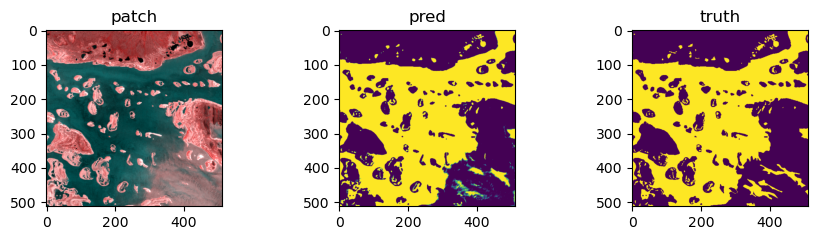

Ep121: tra-> Loss:0.048,Oa:0.972,Miou:0.935,                                 time:9.6s
Ep122: tra-> Loss:0.052,Oa:0.973,Miou:0.931,                                 time:9.7s
Ep123: tra-> Loss:0.046,Oa:0.977,Miou:0.935, val-> Loss:0.057,Oa:0.958, Miou:0.921,time:15.2s
Ep124: tra-> Loss:0.047,Oa:0.970,Miou:0.927,                                 time:9.6s
Ep125: tra-> Loss:0.046,Oa:0.972,Miou:0.927,                                 time:9.7s
Ep126: tra-> Loss:0.046,Oa:0.975,Miou:0.929, val-> Loss:0.056,Oa:0.971, Miou:0.913,time:15.3s
Ep127: tra-> Loss:0.056,Oa:0.973,Miou:0.922,                                 time:9.7s
Ep128: tra-> Loss:0.051,Oa:0.971,Miou:0.930,                                 time:9.7s
Ep129: tra-> Loss:0.059,Oa:0.970,Miou:0.928, val-> Loss:0.057,Oa:0.959, Miou:0.917,time:15.2s
Ep130: tra-> Loss:0.051,Oa:0.973,Miou:0.932,                                 time:9.7s
Ep131: tra-> Loss:0.047,Oa:0.975,Miou:0.937,                                 time:9.6s
Ep132: tra-> Loss:0.05

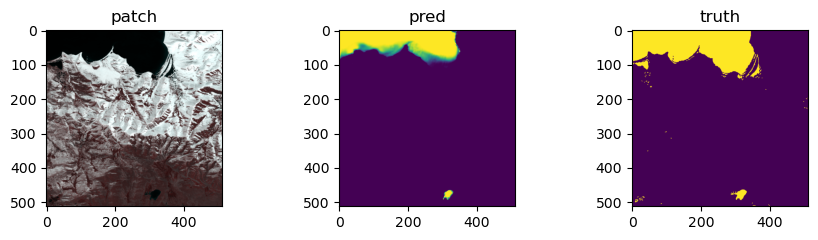

Ep141: tra-> Loss:0.044,Oa:0.974,Miou:0.937, val-> Loss:0.062,Oa:0.960, Miou:0.912,time:15.2s
Ep142: tra-> Loss:0.048,Oa:0.975,Miou:0.940,                                 time:9.7s
Ep143: tra-> Loss:0.045,Oa:0.971,Miou:0.933,                                 time:9.8s
Ep144: tra-> Loss:0.040,Oa:0.979,Miou:0.943, val-> Loss:0.052,Oa:0.960, Miou:0.925,time:15.2s
Ep145: tra-> Loss:0.046,Oa:0.978,Miou:0.939,                                 time:9.7s
Ep146: tra-> Loss:0.041,Oa:0.974,Miou:0.942,                                 time:9.8s
Ep147: tra-> Loss:0.042,Oa:0.978,Miou:0.939, val-> Loss:0.067,Oa:0.958, Miou:0.904,time:15.2s
Ep148: tra-> Loss:0.040,Oa:0.977,Miou:0.942,                                 time:9.7s
Ep149: tra-> Loss:0.045,Oa:0.972,Miou:0.931,                                 time:9.8s
Ep150: tra-> Loss:0.043,Oa:0.976,Miou:0.938, val-> Loss:0.060,Oa:0.960, Miou:0.916,time:15.2s
Ep151: tra-> Loss:0.046,Oa:0.975,Miou:0.935,                                 time:9.7s
Ep152: tra-> Lo

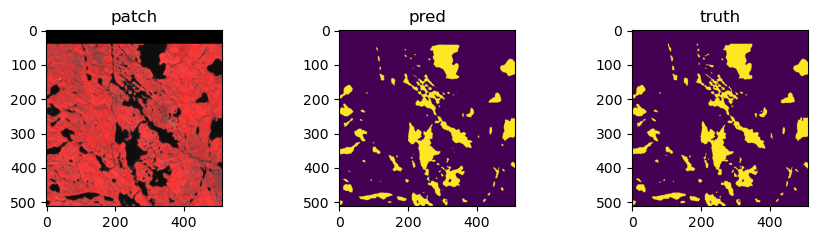

Ep161: tra-> Loss:0.038,Oa:0.978,Miou:0.947,                                 time:9.6s
Ep162: tra-> Loss:0.059,Oa:0.964,Miou:0.918, val-> Loss:0.069,Oa:0.954, Miou:0.900,time:15.2s
Ep163: tra-> Loss:0.049,Oa:0.972,Miou:0.927,                                 time:9.7s
Ep164: tra-> Loss:0.044,Oa:0.974,Miou:0.929,                                 time:9.7s
Ep165: tra-> Loss:0.062,Oa:0.970,Miou:0.923, val-> Loss:0.060,Oa:0.957, Miou:0.915,time:15.4s
Ep166: tra-> Loss:0.050,Oa:0.966,Miou:0.918,                                 time:9.6s
Ep167: tra-> Loss:0.048,Oa:0.975,Miou:0.936,                                 time:9.8s
Ep168: tra-> Loss:0.041,Oa:0.977,Miou:0.942, val-> Loss:0.054,Oa:0.961, Miou:0.926,time:15.2s
Ep169: tra-> Loss:0.042,Oa:0.978,Miou:0.940,                                 time:9.7s
Ep170: tra-> Loss:0.051,Oa:0.975,Miou:0.936,                                 time:9.7s
Ep171: tra-> Loss:0.050,Oa:0.974,Miou:0.925, val-> Loss:0.056,Oa:0.970, Miou:0.912,time:15.2s
Ep172: tra-> Lo

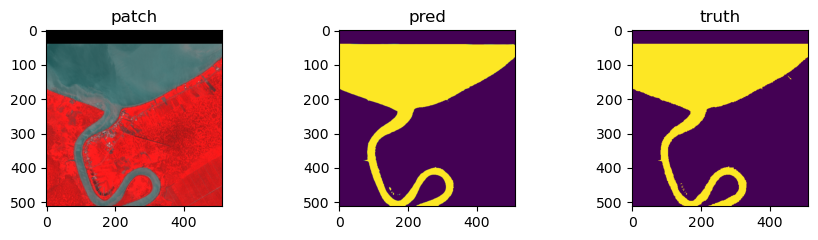

Ep181: tra-> Loss:0.042,Oa:0.977,Miou:0.942,                                 time:9.7s
Ep182: tra-> Loss:0.045,Oa:0.976,Miou:0.935,                                 time:9.8s
Ep183: tra-> Loss:0.045,Oa:0.975,Miou:0.942, val-> Loss:0.068,Oa:0.961, Miou:0.907,time:15.3s
Ep184: tra-> Loss:0.051,Oa:0.972,Miou:0.929,                                 time:9.7s
Ep185: tra-> Loss:0.060,Oa:0.967,Miou:0.921,                                 time:9.7s
Ep186: tra-> Loss:0.050,Oa:0.971,Miou:0.929, val-> Loss:0.054,Oa:0.964, Miou:0.923,time:15.3s
Ep187: tra-> Loss:0.051,Oa:0.969,Miou:0.925,                                 time:9.8s
Ep188: tra-> Loss:0.048,Oa:0.971,Miou:0.935,                                 time:9.7s
Ep189: tra-> Loss:0.041,Oa:0.979,Miou:0.941, val-> Loss:0.053,Oa:0.958, Miou:0.919,time:15.2s
Ep190: tra-> Loss:0.042,Oa:0.975,Miou:0.942,                                 time:9.7s
Ep191: tra-> Loss:0.040,Oa:0.979,Miou:0.948,                                 time:9.7s
Ep192: tra-> Loss:0.04

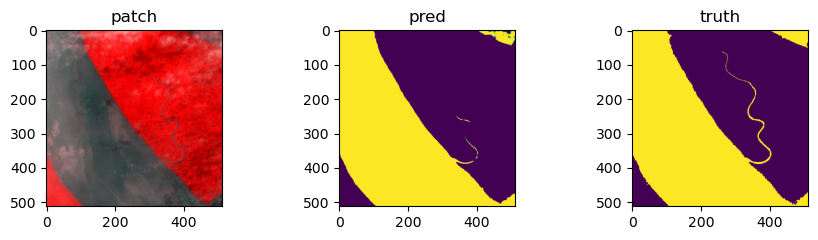

Ep201: tra-> Loss:0.041,Oa:0.978,Miou:0.943, val-> Loss:0.050,Oa:0.973, Miou:0.925,time:15.2s
Ep202: tra-> Loss:0.038,Oa:0.973,Miou:0.939,                                 time:9.7s
Ep203: tra-> Loss:0.037,Oa:0.978,Miou:0.945,                                 time:9.7s
Ep204: tra-> Loss:0.039,Oa:0.979,Miou:0.947, val-> Loss:0.053,Oa:0.964, Miou:0.924,time:15.3s
Ep205: tra-> Loss:0.038,Oa:0.978,Miou:0.945,                                 time:9.7s
Ep206: tra-> Loss:0.043,Oa:0.974,Miou:0.942,                                 time:9.8s
Ep207: tra-> Loss:0.037,Oa:0.980,Miou:0.952, val-> Loss:0.051,Oa:0.960, Miou:0.927,time:15.1s
Ep208: tra-> Loss:0.042,Oa:0.974,Miou:0.933,                                 time:9.8s
Ep209: tra-> Loss:0.040,Oa:0.979,Miou:0.944,                                 time:9.7s
Ep210: tra-> Loss:0.038,Oa:0.978,Miou:0.948, val-> Loss:0.056,Oa:0.955, Miou:0.927,time:15.3s
Ep211: tra-> Loss:0.033,Oa:0.982,Miou:0.953,                                 time:9.6s
Ep212: tra-> Lo

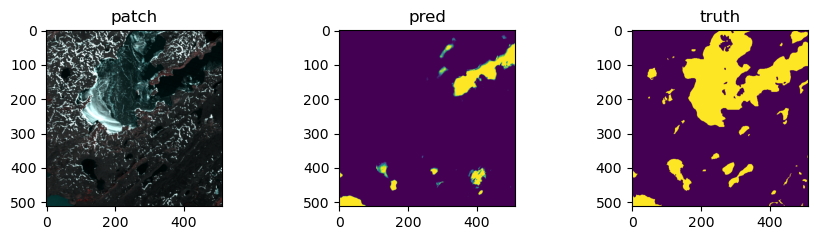

Ep221: tra-> Loss:0.038,Oa:0.980,Miou:0.950,                                 time:9.7s
Ep222: tra-> Loss:0.044,Oa:0.977,Miou:0.940, val-> Loss:0.051,Oa:0.968, Miou:0.934,time:15.2s
Ep223: tra-> Loss:0.043,Oa:0.977,Miou:0.940,                                 time:9.8s
Ep224: tra-> Loss:0.045,Oa:0.974,Miou:0.936,                                 time:9.7s
Ep225: tra-> Loss:0.050,Oa:0.975,Miou:0.934, val-> Loss:0.080,Oa:0.951, Miou:0.918,time:15.3s
Ep226: tra-> Loss:0.052,Oa:0.972,Miou:0.932,                                 time:9.7s
Ep227: tra-> Loss:0.046,Oa:0.973,Miou:0.928,                                 time:9.7s
Ep228: tra-> Loss:0.038,Oa:0.977,Miou:0.944, val-> Loss:0.053,Oa:0.962, Miou:0.919,time:15.3s
Ep229: tra-> Loss:0.040,Oa:0.978,Miou:0.941,                                 time:9.7s
Ep230: tra-> Loss:0.041,Oa:0.977,Miou:0.938,                                 time:9.7s
Ep231: tra-> Loss:0.037,Oa:0.980,Miou:0.946, val-> Loss:0.049,Oa:0.968, Miou:0.928,time:15.3s
Ep232: tra-> Lo

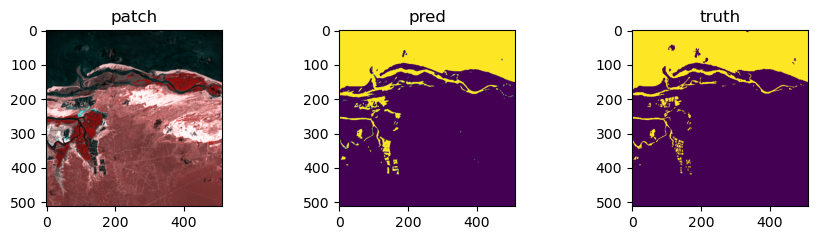

Ep241: tra-> Loss:0.046,Oa:0.973,Miou:0.932,                                 time:9.7s
Ep242: tra-> Loss:0.045,Oa:0.977,Miou:0.941,                                 time:9.6s
Ep243: tra-> Loss:0.041,Oa:0.978,Miou:0.942, val-> Loss:0.058,Oa:0.959, Miou:0.920,time:15.2s
Ep244: tra-> Loss:0.041,Oa:0.979,Miou:0.935,                                 time:9.6s
Ep245: tra-> Loss:0.035,Oa:0.979,Miou:0.946,                                 time:9.7s
Ep246: tra-> Loss:0.039,Oa:0.979,Miou:0.942, val-> Loss:0.050,Oa:0.965, Miou:0.930,time:15.3s
Ep247: tra-> Loss:0.041,Oa:0.980,Miou:0.947,                                 time:9.7s
Ep248: tra-> Loss:0.041,Oa:0.977,Miou:0.942,                                 time:9.8s
Ep249: tra-> Loss:0.039,Oa:0.975,Miou:0.937, val-> Loss:0.051,Oa:0.965, Miou:0.929,time:15.2s
Ep250: tra-> Loss:0.037,Oa:0.979,Miou:0.945,                                 time:9.8s
Ep251: tra-> Loss:0.037,Oa:0.980,Miou:0.947,                                 time:9.7s
Ep252: tra-> Loss:0.03

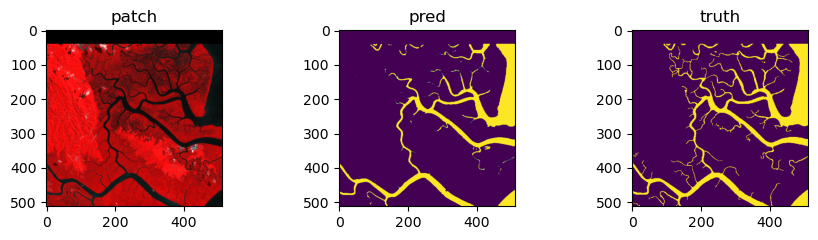

Ep261: tra-> Loss:0.033,Oa:0.981,Miou:0.951, val-> Loss:0.047,Oa:0.969, Miou:0.934,time:15.4s
Ep262: tra-> Loss:0.038,Oa:0.977,Miou:0.943,                                 time:9.8s
Ep263: tra-> Loss:0.041,Oa:0.977,Miou:0.940,                                 time:9.7s
Ep264: tra-> Loss:0.037,Oa:0.980,Miou:0.946, val-> Loss:0.048,Oa:0.971, Miou:0.930,time:15.3s
Ep265: tra-> Loss:0.036,Oa:0.980,Miou:0.949,                                 time:9.6s
Ep266: tra-> Loss:0.040,Oa:0.980,Miou:0.946,                                 time:9.7s
Ep267: tra-> Loss:0.041,Oa:0.977,Miou:0.939, val-> Loss:0.060,Oa:0.962, Miou:0.899,time:15.3s
Ep268: tra-> Loss:0.044,Oa:0.975,Miou:0.928,                                 time:9.8s
Ep269: tra-> Loss:0.044,Oa:0.977,Miou:0.941,                                 time:9.7s
Ep270: tra-> Loss:0.039,Oa:0.980,Miou:0.942, val-> Loss:0.051,Oa:0.961, Miou:0.919,time:15.3s
Ep271: tra-> Loss:0.040,Oa:0.978,Miou:0.941,                                 time:9.6s
Ep272: tra-> Lo

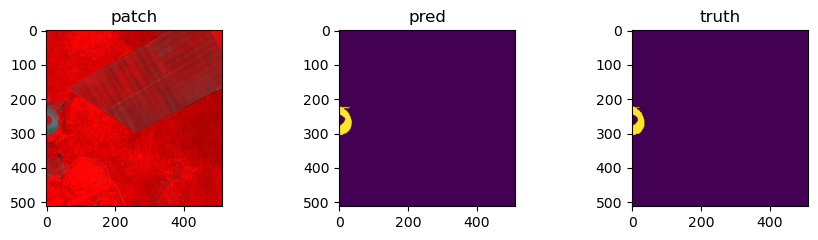

Ep281: tra-> Loss:0.035,Oa:0.982,Miou:0.952,                                 time:9.7s
Ep282: tra-> Loss:0.034,Oa:0.981,Miou:0.950, val-> Loss:0.051,Oa:0.967, Miou:0.924,time:15.3s
Ep283: tra-> Loss:0.036,Oa:0.981,Miou:0.947,                                 time:9.6s
Ep284: tra-> Loss:0.034,Oa:0.983,Miou:0.953,                                 time:9.7s
Ep285: tra-> Loss:0.031,Oa:0.980,Miou:0.948, val-> Loss:0.051,Oa:0.971, Miou:0.927,time:15.2s
Ep286: tra-> Loss:0.036,Oa:0.980,Miou:0.949,                                 time:9.7s
Ep287: tra-> Loss:0.040,Oa:0.979,Miou:0.950,                                 time:9.7s
Ep288: tra-> Loss:0.035,Oa:0.982,Miou:0.951, val-> Loss:0.052,Oa:0.961, Miou:0.928,time:15.3s
Ep289: tra-> Loss:0.032,Oa:0.982,Miou:0.955,                                 time:9.6s
Ep290: tra-> Loss:0.034,Oa:0.982,Miou:0.949,                                 time:9.7s
Ep291: tra-> Loss:0.034,Oa:0.982,Miou:0.951, val-> Loss:0.052,Oa:0.965, Miou:0.929,time:15.4s
Ep292: tra-> Lo

In [10]:
device = torch.device('cuda:0') 
metrics = train_loops(model=model, 
                epoches=300,  
                loss_fn=criterion ,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [11]:
# # model saving 
# model_name = 'unet_att'  ## model name setting for saving
# date_str = time.strftime("%Y-%m-%d-%H",   time.localtime())
# date_str = date_str.replace('-', '')  ## remove '-' for file namestrings 
# path_save = f'model/trained/{model_name}_weights_{date_str}.pth'
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# # # model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# # # ## metrics saving
# path_metrics = f'model/trained/{model_name}_metrics_{date_str}.csv'    
# # path_metrics = f'model/trained/patch_{patch_size}/{model_name}_metrics_1.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
